In [9]:
# pandasライブラリを読み込む
import pandas as pd

# csvファイルを読み込む（データフレームとして呼び出される）
df = pd.read_csv('train.csv')
# 先頭から5行目までのデータを表示する
df.head()

# Pythonはインデックスが0から始まるので、
# 3行目を指定するときは1を足して2になります。
df.loc[[2]]

# 以下のように書くとデータフレームではなくシリーズとして取り出されます。
df.loc[2]

df.query('POSTED_BY == "Owner"')

df.loc[[df['TARGET(PRICE_IN_LACS)'].idxmax()]]

# 物件価格の最大を求める
df['TARGET(PRICE_IN_LACS)'].max()

# 物件価格の最小を求める
df['TARGET(PRICE_IN_LACS)'].min()

# 物件価格の平均を求める
df['TARGET(PRICE_IN_LACS)'].mean()

df['TARGET(PRICE_IN_LACS)'].describe()

,TARGET(PRICE_IN_LACS)
count,29451.000000
mean,142.898746
std,656.880713
min,0.250000
25%,38.000000
50%,62.000000
75%,100.000000
max,30000.000000


In [26]:
# 初回のみライブラリをインポートする
import pandas as pd

# csvファイルをデータフレームとして読み込む
df = pd.read_csv("sample_pandas_6.csv")
# 先頭から5行目までを表示する
df.head()

df.query('商品番号 == "Z4WOOIYV"')

df.query('単価 == 600')

df.query('在庫 <= 5')

df.query('商品番号 == "8T7D5DQA" and 在庫 <= 5')

def tax(x):
    return x * 1.10

df['単価'].apply(tax)

type(df['発注日'].loc[0])

df['発注日'] = pd.to_datetime(df['発注日'])

type(pd.to_datetime(df['発注日']).loc[0])

df.agg({'発注日':['max', 'min']})

tax_series = df['単価'].apply(tax)
tax_series.name = "単価（税込み）"
pd.concat([df, tax_series], axis=1)

category_df = pd.read_csv('category.csv')
category_df

df = pd.merge(df, category_df[['商品番号', 'カテゴリー']], how='inner', on='商品番号')
df


In [27]:
df = pd.merge(df, category_df[['商品番号', 'カテゴリー']], how='inner', on='商品番号')
df

,発注日,商品番号,商品名,単価,在庫,注文数,カテゴリー_x,カテゴリー_y,カテゴリー
0,2016-03-06,YY4HAAZR,商品サンプル YY4HAAZR,780,20,24,弁当,弁当,弁当
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12,飲料水,飲料水,飲料水
2,2017-05-31,YY4HAAZR,商品サンプル YY4HAAZR,780,10,0,弁当,弁当,弁当
3,2022-10-26,1QJFO8QY,商品サンプル 1QJFO8QY,600,5,24,弁当,弁当,弁当
4,2016-06-10,1QJFO8QY,商品サンプル 1QJFO8QY,600,40,24,弁当,弁当,弁当
...,...,...,...,...,...,...,...,...,...
195,2021-08-02,1QJFO8QY,商品サンプル 1QJFO8QY,600,10,42,弁当,弁当,弁当
196,2019-05-28,X0ZE2ZMY,商品サンプル X0ZE2ZMY,90,45,30,飲料水,飲料水,飲料水
197,2015-06-22,48XMJXKO,商品サンプル 48XMJXKO,330,50,36,デザート,デザート,デザート
198,2022-08-29,QRMOGNUU,商品サンプル QRMOGNUU,420,40,48,雑貨,雑貨,雑貨


In [28]:
category_count = df['カテゴリー'].value_counts()
category_count

,count
カテゴリー,
弁当,49
菓子類,38
飲料水,36
デザート,30
雑貨,27
図書・新聞,20


NameError: name 'plt' is not defined

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24321 (\N{CJK UNIFIED IDEOGRAPH-5F01}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 33747 (\N{CJK UNIFIED IDEOGRAPH-83D3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph

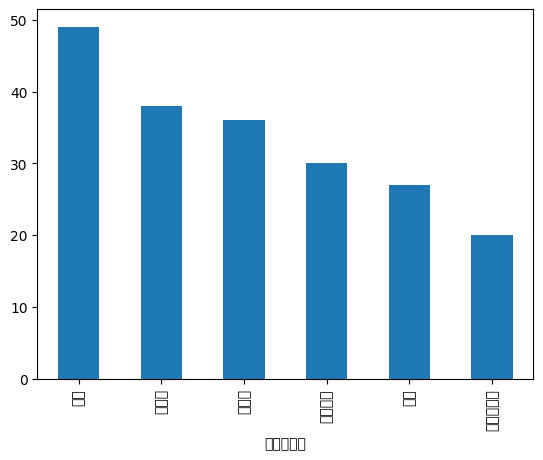

In [29]:
category_count.plot(kind='bar')

plt.title('カテゴリーごとの出現頻度')
plt.xlabel('カテゴリー')
plt.ylabel('出現回数')

plt.show()

In [30]:
df.groupby('商品番号')['注文数'].describe()

,count,mean,std,min,25%,50%,75%,max
商品番号,,,,,,,,
1QJFO8QY,32.0,35.250000,18.461818,0.0,24.0,36.0,49.5,60.0
2HSTCDWM,20.0,29.400000,21.137146,0.0,12.0,27.0,48.0,60.0
48XMJXKO,10.0,21.600000,13.326665,0.0,13.5,21.0,30.0,42.0
8T7D5DQA,21.0,25.142857,18.260027,0.0,12.0,36.0,42.0,54.0
MESUDVWQ,17.0,43.764706,18.219253,0.0,42.0,48.0,54.0,60.0
QRMOGNUU,27.0,33.111111,16.588535,6.0,21.0,36.0,48.0,60.0
S6RE8W6X,20.0,33.300000,21.631118,0.0,12.0,39.0,54.0,60.0
X0ZE2ZMY,14.0,21.857143,21.901377,0.0,1.5,15.0,39.0,60.0
YY4HAAZR,17.0,31.764706,18.095336,0.0,18.0,30.0,42.0,60.0


In [31]:
category_count = df['カテゴリー'].value_counts()
category_count

,count
カテゴリー,
弁当,49
菓子類,38
飲料水,36
デザート,30
雑貨,27
図書・新聞,20


NameError: name 'plt' is not defined

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24321 (\N{CJK UNIFIED IDEOGRAPH-5F01}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 33747 (\N{CJK UNIFIED IDEOGRAPH-83D3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph

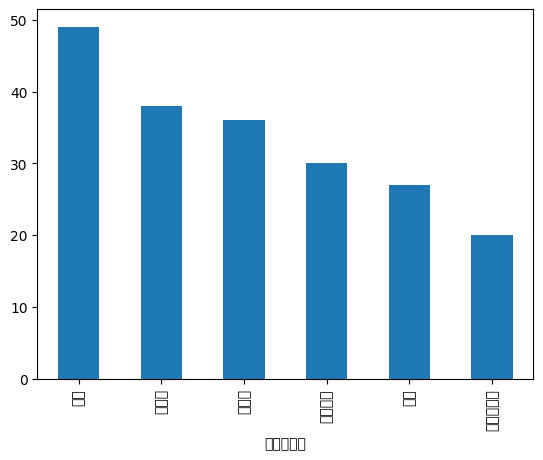

In [32]:
category_count.plot(kind='bar')

plt.title('カテゴリーごとの出現頻度')
plt.xlabel('カテゴリー')
plt.ylabel('出現回数')

plt.show()

In [33]:
df.groupby('商品番号')['注文数'].describe()

,count,mean,std,min,25%,50%,75%,max
商品番号,,,,,,,,
1QJFO8QY,32.0,35.250000,18.461818,0.0,24.0,36.0,49.5,60.0
2HSTCDWM,20.0,29.400000,21.137146,0.0,12.0,27.0,48.0,60.0
48XMJXKO,10.0,21.600000,13.326665,0.0,13.5,21.0,30.0,42.0
8T7D5DQA,21.0,25.142857,18.260027,0.0,12.0,36.0,42.0,54.0
MESUDVWQ,17.0,43.764706,18.219253,0.0,42.0,48.0,54.0,60.0
QRMOGNUU,27.0,33.111111,16.588535,6.0,21.0,36.0,48.0,60.0
S6RE8W6X,20.0,33.300000,21.631118,0.0,12.0,39.0,54.0,60.0
X0ZE2ZMY,14.0,21.857143,21.901377,0.0,1.5,15.0,39.0,60.0
YY4HAAZR,17.0,31.764706,18.095336,0.0,18.0,30.0,42.0,60.0
